# Notebook de obtención, limpieza y transformación de datos — Fase 2

**Proyecto:** Predicción de accidente cerebrovascular (*stroke*)

---

### ¿Qué es un *pipeline* de preprocesamiento?

Un *pipeline* es una secuencia ordenada de pasos por los que pasan los datos crudos hasta
quedar listos para analizar o modelar. En este notebook el flujo es:

**Obtener → Explorar → Limpiar → Transformar → Escalar → Validar**

Cada paso se implementa como una **función** reutilizable. Trabajar con funciones (en vez
de copiar y pegar código) hace el proceso más ordenado, más fácil de corregir y permite
reutilizar la misma lógica sobre cualquier columna sin reescribirla.

## Introducción

Según la Organización Mundial de la Salud, el accidente cerebrovascular es la segunda
causa de muerte a nivel mundial. Este conjunto de datos permite predecir la probabilidad
de que un paciente sufra un accidente cerebrovascular a partir de variables como el sexo,
la edad, distintas enfermedades y el estado de tabaquismo.

**Objetivo general (Fase 2).** Construir un *pipeline* reproducible que deje el *dataset*
limpio, codificado y escalado, listo para el modelado posterior.

**Objetivos específicos.**
- Obtener y explorar los datos verificando su estructura y calidad.
- Limpiar gestionando rigurosamente los valores nulos.
- Transformar las variables categóricas nominales con codificación One-Hot.
- Estandarizar las variables continuas.
- Validar técnicamente el resultado.

**Atributos:** `id`, `gender`, `age`, `hypertension`, `heart_disease`, `ever_married`,
`work_type`, `Residence_type`, `avg_glucose_level`, `bmi`, `smoking_status` y la variable
objetivo `stroke` (1 = sufrió accidente cerebrovascular, 0 = no).

### Librerías utilizadas

| Librería | Para qué la usamos |
|---|---|
| `numpy` | Cálculo numérico y manejo de arreglos. |
| `pandas` | Cargar y manipular la tabla de datos (el `DataFrame`). |
| `matplotlib` | Generar los gráficos (*boxplots*). |
| `sklearn.preprocessing` | Las herramientas de codificación (`LabelEncoder`, `OneHotEncoder`) y escalamiento (`StandardScaler`). |

`np.random.seed(42)` fija la semilla aleatoria: garantiza que cualquier proceso con azar
dé **siempre el mismo resultado**, lo que asegura la *reproducibilidad* exigida en la fase.

In [4]:
import numpy as np                  # cálculo numérico y operaciones vectorizadas
import pandas as pd                 # estructuras tabulares: Series y DataFrame
import matplotlib.pyplot as plt     # gráficos de control
from sklearn import preprocessing    # LabelEncoder y OneHotEncoder
from sklearn.preprocessing import StandardScaler   # estandarización z-score

# Reproducibilidad: fijamos la semilla aleatoria del entorno
np.random.seed(42)

%matplotlib inline

## Configuración del entorno y de las rutas

Antes de cargar nada conviene comprobar el entorno y dejar declaradas las rutas.
Se usan rutas **relativas** a la raíz del repositorio, coherentes con la
estructura creada en la Fase 1: una ruta absoluta como `C:/Users/...` funciona en
un solo computador del mundo.

In [5]:
from pathlib import Path      # manejo de rutas independiente del sistema operativo
import sys

# sys.version trae la versión completa con fecha de compilación;
# split()[0] deja solo el número, que es lo único que hay que comprobar.
print("Python:", sys.version.split()[0])
for lib, mod in [("numpy", np), ("pandas", pd)]:
    print(f"{lib:8}:", mod.__version__)

# Estructura del proyecto. parents=True crea las carpetas intermedias;
# exist_ok=True evita el error si ya existen.
DIR_CRUDO = Path("data/raw")            # datos originales: nunca se modifican
DIR_PROCESADO = Path("data/processed")  # resultado del pipeline
DIR_DOCS = Path("docs")                 # diccionario, bitácora y metadatos
for carpeta in (DIR_CRUDO, DIR_PROCESADO, DIR_DOCS):
    carpeta.mkdir(parents=True, exist_ok=True)

ARCHIVO = DIR_CRUDO / "healthcare-dataset-stroke-data.csv"
print("\nArchivo esperado en:", ARCHIVO)

Python: 3.13.9
numpy   : 2.5.2
pandas  : 3.0.5

Archivo esperado en: data/raw/healthcare-dataset-stroke-data.csv


### Procedencia del conjunto de datos

| Campo | Valor |
| --- | --- |
| Título | Stroke Prediction Dataset |
| Autor | fedesoriano |
| Plataforma | Kaggle |
| Enlace | `https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset` |
| Estructura esperada | 5.110 filas × 12 columnas · 201 nulos en `bmi` |
| Unidad de observación | Un paciente |

**Referencia en APA 7 para el informe:**

> fedesoriano. (2021). *Stroke Prediction Dataset* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

Documentar la procedencia no es un trámite: sin ella, nadie puede verificar sobre
qué versión del archivo se trabajó.

In [3]:
# Reemplaza el nombre por el de tu archivo real
# Buscar el dataset desde la carpeta superior del proyecto
base = Path.cwd().parent

archivo = next(
    base.rglob("healthcare-dataset-stroke-data.csv"),
    None
)

if archivo is None:
    raise FileNotFoundError(
        f"No se encontró el dataset dentro de:\n{base}"
    )

print("Dataset encontrado en:")
print(archivo)

df = pd.read_csv(archivo)

print(f"\nDataset cargado correctamente")
print(f"Dimensiones: {df.shape}")

df.head()

Dataset encontrado en:
/Users/omarsalinas/intake_mcdi500_2/Material_Didactico_Semana1/proyecto-grupoX-mcdi500/data/raw/healthcare-dataset-stroke-data.csv

Dataset cargado correctamente
Dimensiones: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 1. Obtención de los datos

**Qué hace este paso.** Lee el archivo CSV y lo carga en un `DataFrame` (la tabla con la
que trabajaremos).

**Por qué con una función.** Encapsulamos la lectura en `cargar_datos(ruta)` con un bloque
`try / except`. Así, si el archivo no existe, en lugar de un error técnico confuso, el
usuario recibe un mensaje claro indicando qué revisar. La función, además, imprime las
dimensiones cargadas, lo que sirve como primera verificación de que el archivo se leyó bien.

Es una función (def) que recibe un parámetro, ruta (el nombre del archivo), y se encarga de leer el CSV. El texto entre """...""" es el docstring: solo documentación, no se ejecuta. El bloque try/except maneja errores: intenta leer el archivo con pd.read_csv(ruta) y, si no lo encuentra, en vez de romperse muestra un mensaje claro de qué revisar (usando un f-string, que inserta el valor de ruta en el texto). Luego print informa el tamaño con df.shape[0] (filas) y df.shape[1] (columnas) —de ahí el "5110 filas y 12 columnas"— y return df entrega la tabla para usarla después. Al final, df = cargar_datos("...") llama a la función y guarda el resultado en df.

In [32]:
from pathlib import Path
import pandas as pd

# El notebook está en F2 y el dataset está en F1/data/raw
ARCHIVO = Path("../F1/data/raw/healthcare-dataset-stroke-data.csv")

print("Directorio actual:")
print(Path.cwd())

print("\nRuta del archivo:")
print(ARCHIVO.resolve())

print("\n¿Existe el archivo?")
print(ARCHIVO.exists())

# Validación
if not ARCHIVO.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo en:\n{ARCHIVO.resolve()}"
    )

# Cargar dataset
df_crudo = pd.read_csv(
    ARCHIVO,
    na_values=["N/A"]
)

# Mantener copia original
df = df_crudo.copy()

print("\nDatos cargados correctamente")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Directorio actual:
/Users/omarsalinas/intake_mcdi500_2/Material_Didactico_Semana1/proyecto-grupoX-mcdi500/F2

Ruta del archivo:
/Users/omarsalinas/intake_mcdi500_2/Material_Didactico_Semana1/proyecto-grupoX-mcdi500/F1/data/raw/healthcare-dataset-stroke-data.csv

¿Existe el archivo?
True

Datos cargados correctamente
Filas: 5110
Columnas: 12


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Mostramos las primeras filas para confirmar visualmente que las columnas se cargaron correctamente:

`head()` muestra las primeras cinco filas. Es la comprobación más barata que existe: confirma que el separador se interpretó bien, que los nombres de columna son los esperados y que los valores no quedaron corridos de columna.

> **Qué mirar aquí.** Que `bmi` aparezca como número y no como texto. Si el archivo trae los faltantes escritos como `N/A`, pandas los reconoce; si vinieran como `--` o `sin dato`, la columna entera se cargaría como texto y todas las operaciones numéricas fallarían más adelante.

In [33]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Exploración inicial

**Qué hace este paso.** Antes de modificar nada, miramos el estado original de los datos.
Esto nos da la "línea base" contra la cual verificaremos después cada transformación.

La función `explorar_dataframe` reporta cuatro cosas:
1. **Dimensiones** (`shape`): cuántas filas y columnas hay.
2. **Tipos de datos** (`dtypes`): qué columnas son numéricas y cuáles son texto. Las de
   texto (`object`) son las que tendremos que codificar más adelante.
3. **Valores nulos** (`isnull().sum()`): cuántos datos faltan en cada columna. Aquí
   detectaremos que `bmi` tiene huecos.
4. **Estadísticos descriptivos** (`describe()`): media, mínimo, máximo, etc., de las
   variables numéricas, útil para detectar rangos raros o valores atípicos.

In [34]:
def explorar_dataframe(df):
    """Resumen exploratorio: dimensiones, tipos, nulos y estadisticos descriptivos."""
    print("Dimensiones:", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nValores nulos por columna:")
    print(df.isnull().sum())
    print("\nEstadisticos descriptivos (variables numericas):")
    return df.describe()


explorar_dataframe(df)

Dimensiones: (5110, 12)

Tipos de datos:
id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

Valores nulos por columna:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Estadisticos descriptivos (variables numericas):


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


También revisamos **cuántas categorías distintas** tiene cada variable de texto y cuántas
veces aparece cada una. Esto cumple dos funciones: detectar errores de tipeo o categorías
inesperadas, y conocer el orden en que aparecerán las categorías al codificarlas.

In [35]:
# Conteo de categorias en las variables nominales (control de calidad de entrada)
columnas_categoricas = ['gender', 'ever_married', 'work_type',
                        'Residence_type', 'smoking_status']
for col in columnas_categoricas:
    print(f"\n{col}:")
    # dropna=False incluye los nulos como una categoría más: si una variable
    # tiene faltantes queremos verlos aquí, no que desaparezcan del conteo.
    print(df[col].value_counts(dropna=False))


gender:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

ever_married:
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

work_type:
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Residence_type:
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


### El diccionario de variables

Antes de limpiar hay que declarar **qué es cada variable**. Esta es la decisión
que determina todo el preprocesamiento posterior.

La idea central: **el tipo de dato no dice qué es una variable**. En este
conjunto `hypertension`, `id` y `age` son todas numéricas, y sin embargo exigen
tratamientos completamente distintos.

| Rol analítico | Qué preprocesamiento exige |
| --- | --- |
| **Continua** | Detección de atípicos, imputación, escalamiento |
| **Binaria** | Codificación 0/1 y revisión de desbalance |
| **Nominal** | *One-hot encoding* |
| **Ordinal** | Codificación con el orden declarado explícitamente |
| **Identificador** | Verificar unicidad y excluir del análisis |
| **Objetivo** | Se preserva sin transformar en esta fase |

In [36]:
# El diccionario se DECLARA con lo que se sabe del dominio y se COMPLETA con lo
# observado en el archivo: no se afirma nada que no se verifique.
DECLARADO = [
    ("id",                "identificador", "Identificador único del paciente"),
    ("gender",            "nominal",       "Female, Male, Other"),
    ("age",               "continua",      "Edad en años"),
    ("hypertension",      "binaria",       "1 si presenta hipertensión diagnosticada"),
    ("heart_disease",     "binaria",       "1 si presenta cardiopatía"),
    ("ever_married",      "nominal",       "Yes / No"),
    ("work_type",         "nominal",       "Tipo de ocupación"),
    ("Residence_type",    "nominal",       "Urban / Rural"),
    ("avg_glucose_level", "continua",      "Glucosa promedio en sangre"),
    ("bmi",               "continua",      "Índice de masa corporal"),
    ("smoking_status",    "ordinal",       "Unknown < never < formerly < smokes"),
    ("stroke",            "objetivo",      "1 si el paciente presentó el evento"),
]
diccionario = pd.DataFrame(DECLARADO, columns=["variable", "rol", "descripcion"])

# Columnas OBSERVADAS: se leen del archivo, no se escriben a mano
diccionario["dtype"] = [str(df_crudo[v].dtype) for v in diccionario["variable"]]
# nunique() cuenta valores distintos: distingue una binaria de una continua
diccionario["n_unicos"] = [int(df_crudo[v].nunique()) for v in diccionario["variable"]]
# Sobre booleanos, mean() devuelve la PROPORCIÓN de True: por 100 da el porcentaje
diccionario["pct_nulos"] = [round(df_crudo[v].isna().mean() * 100, 1)
                            for v in diccionario["variable"]]

# El diccionario es un entregable, no una tabla de paso: se guarda
diccionario.to_csv(DIR_DOCS / "diccionario_variables.csv", index=False)
diccionario

,variable,rol,descripcion,dtype,n_unicos,pct_nulos
0,id,identificador,Identificador único del paciente,int64,5110,0.0
1,gender,nominal,"Female, Male, Other",str,3,0.0
2,age,continua,Edad en años,float64,104,0.0
3,hypertension,binaria,1 si presenta hipertensión diagnosticada,int64,2,0.0
4,heart_disease,binaria,1 si presenta cardiopatía,int64,2,0.0
5,ever_married,nominal,Yes / No,str,2,0.0
6,work_type,nominal,Tipo de ocupación,str,5,0.0
7,Residence_type,nominal,Urban / Rural,str,2,0.0
8,avg_glucose_level,continua,Glucosa promedio en sangre,float64,3979,0.0
9,bmi,continua,Índice de masa corporal,float64,418,3.9


### Valores atípicos: medir antes de decidir

La sección siguiente imputa con la mediana «porque hay valores extremos». Esa
afirmación hay que **demostrarla**, no enunciarla. Se usa el criterio del rango
intercuartílico:

$$\text{atípico si} \quad x < Q_1 - 1{,}5 \cdot \text{RIC} \quad \text{o} \quad x > Q_3 + 1{,}5 \cdot \text{RIC}$$

In [37]:
def detectar_atipicos_iqr(serie, factor=1.5):
    """Identifica valores atípicos por el criterio del rango intercuartílico.

    Retorna
    -------
    tuple(np.ndarray, float, float)
        Máscara booleana de atípicos, límite inferior y límite superior.
    """
    # dropna() es obligatorio: un NaN propagaría y devolvería NaN como cuartil
    valores = serie.dropna().to_numpy(dtype="float64")

    # np.percentile con una lista devuelve varios percentiles de una vez
    q1, q3 = np.percentile(valores, [25, 75])
    ric = q3 - q1                                  # rango intercuartílico
    limite_inf, limite_sup = q1 - factor * ric, q3 + factor * ric

    # El operador | es el "o" elemento a elemento de pandas. Con 'or' fallaría:
    # 'or' espera un único booleano, no una serie completa.
    mascara = (serie < limite_inf) | (serie > limite_sup)
    # Comparar con NaN da False pero deja NA: fillna(False) lo hace explícito
    return mascara.fillna(False).to_numpy(), limite_inf, limite_sup


filas = []
for col in ["age", "avg_glucose_level", "bmi"]:
    mascara, inf, sup = detectar_atipicos_iqr(df[col])
    filas.append({
        "variable": col,
        "limite_inf": round(inf, 2),
        "limite_sup": round(sup, 2),
        "n_atipicos": int(mascara.sum()),          # sobre booleanos, sum() cuenta True
        "pct_atipicos": round(mascara.mean() * 100, 2),
        "media": round(df[col].mean(), 2),
        "mediana": round(df[col].median(), 2),
    })
pd.DataFrame(filas)

,variable,limite_inf,limite_sup,n_atipicos,pct_atipicos,media,mediana
0,age,-29.00,115.00,0,0.00,43.23,45.00
1,avg_glucose_level,21.98,169.36,627,12.27,106.15,91.88
2,bmi,9.10,47.50,110,2.15,28.89,28.10


> **Cómo se lee esta tabla.** Donde la **media se aleja de la mediana** hay
> asimetría: la media queda arrastrada por los valores extremos. Ese es el
> argumento técnico —no una preferencia— para imputar con la mediana. Escríbanlo
> así en el informe, con las cifras de su propio conjunto.

## 3. Limpieza de datos

Limpiar significa dejar los datos completos y consistentes. Tomamos dos decisiones, cada
una justificada técnicamente:

**a) Eliminar `id`.** Es un identificador único (un número distinto por paciente). No
contiene información que ayude a predecir el accidente cerebrovascular, así que lo
descartamos para que no introduzca ruido.

**b) Imputar `bmi` con la mediana.** `bmi` (índice de masa corporal) es la única columna
con valores faltantes. "Imputar" es rellenar esos huecos con un valor representativo.
Tenemos dos opciones:
- La **media** (promedio): se ve arrastrada por los valores extremos.
- La **mediana** (valor central): es **robusta** ante valores atípicos.

Como el `bmi` tiene valores atípicos (se ven en el *boxplot* del final), usar la mediana
evita que esos extremos sesguen el relleno. La función `imputar_nulos_numericos` permite
elegir la estrategia con un parámetro e informa cuántos nulos rellenó y con qué valor
(trazabilidad).

In [38]:
def imputar_nulos_numericos(df, columna, estrategia="mediana"):
    """
    Imputa los valores nulos de una columna numerica.

    Parametros
    ----------
    df : pd.DataFrame
    columna : str
        Columna numerica a imputar.
    estrategia : str
        'media' o 'mediana'.

    Retorna
    -------
    pd.DataFrame
        DataFrame con la columna imputada.
    """
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")
    # isnull() da True/False por celda; sum() cuenta los True.
    # Se calcula ANTES de imputar: después ya no habría nulos que contar.
    n_nulos = int(df[columna].isnull().sum())
    if estrategia == "media":
        valor = df[columna].mean()
    elif estrategia == "mediana":
        valor = df[columna].median()
    else:
        raise ValueError("estrategia debe ser 'media' o 'mediana'")
    df = df.copy()
    df[columna] = df[columna].fillna(valor)
    print(f"'{columna}': {n_nulos} nulos imputados con la {estrategia} = {valor:.2f}")
    return df

**Antes** de limpiar, confirmamos dónde están los nulos:

In [39]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Eliminamos el identificador `id`:

In [40]:
# Antes de descartarlo se comprueba que 'id' sea efectivamente un identificador:
# is_unique devuelve True si no hay valores repetidos.
assert df['id'].is_unique, "'id' tiene valores repetidos: revísalo antes de descartarlo"

# drop(columns=[...]) devuelve un DataFrame NUEVO sin esa columna.
df = df.drop(columns=['id'])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Imputamos los nulos de `bmi` con la mediana:

In [41]:
df = imputar_nulos_numericos(df, "bmi", estrategia="mediana")

'bmi': 201 nulos imputados con la mediana = 28.10


### Comparar los métodos antes de elegir

La celda anterior aplica la mediana. Falta lo que la rúbrica evalúa: **por qué
esa y no otra**. Ninguna estrategia es mejor en abstracto.

| Método | Cuándo conviene | Qué distorsiona |
| --- | --- | --- |
| **Eliminar filas** | Faltantes escasos y aparentemente aleatorios | Pierde muestra; sesga si no son aleatorios |
| **Media** | Distribución aproximadamente simétrica | La arrastran los extremos; reduce la dispersión |
| **Mediana** | Hay valores extremos o asimetría | Reduce la dispersión; ignora las demás variables |
| **Mediana por grupo** | El valor depende de otra variable observada | Reduce la dispersión dentro de cada grupo |

In [42]:
def comparar_imputaciones(datos, columna, agrupador=None, n_grupos=4):
    """Compara el efecto de cuatro estrategias de imputación sobre una variable.

    Retorna
    -------
    pd.DataFrame con el efecto de cada estrategia sobre la distribución.
    """
    original = datos[columna]
    if original.isna().sum() == 0:            # sin faltantes no hay nada que comparar
        raise ValueError(f"'{columna}' no tiene valores faltantes.")

    resultados = {
        "sin imputar (referencia)": original.dropna(),
        "eliminar filas": original.dropna(),
        "media": original.fillna(original.mean()),
        "mediana": original.fillna(original.median()),
    }
    if agrupador is not None:
        # qcut corta en tramos con la MISMA cantidad de casos (cuartiles si q=4);
        # duplicates="drop" evita el error cuando dos cortes coinciden.
        tramos = pd.qcut(datos[agrupador], q=n_grupos, duplicates="drop")
        # transform("median") devuelve una serie del MISMO largo, con la mediana
        # del grupo en cada fila. Con agg() se obtendría una fila por grupo,
        # que no sirve para rellenar.
        resultados["mediana por grupo"] = original.fillna(
            original.groupby(tramos, observed=True).transform("median"))

    filas = [{
        "estrategia": nombre,
        "n": len(serie.dropna()),
        "media": round(serie.mean(), 3),
        "desv_est": round(serie.std(), 3),
        "asimetria": round(serie.skew(), 3),     # skew() mide la cola de la distribución
    } for nombre, serie in resultados.items()]

    tabla = pd.DataFrame(filas)
    referencia = tabla.iloc[0]["desv_est"]       # iloc[0] es la fila de referencia
    # La columna decisiva: cuánto deforma cada método la dispersión original
    tabla["cambio_desv_%"] = ((tabla["desv_est"] - referencia) / referencia * 100).round(2)
    tabla["filas_perdidas"] = len(datos) - tabla["n"]
    return tabla


comparar_imputaciones(df_crudo, "bmi", agrupador="age")

,estrategia,n,media,desv_est,asimetria,cambio_desv_%,filas_perdidas
0,sin imputar (referencia),4909,28.893,7.854,1.055,0.00,201
1,eliminar filas,4909,28.893,7.854,1.055,0.00,201
2,media,5110,28.893,7.698,1.077,-1.99,0
3,mediana,5110,28.862,7.700,1.088,-1.96,0
4,mediana por grupo,5110,28.873,7.717,1.072,-1.74,0


**Cómo se lee.** `cambio_desv_%` es la columna que decide: toda imputación por
un valor central concentra los datos y **reduce artificialmente la desviación
estándar**. El método que menos la reduce es el que menos deforma la variable.
`filas_perdidas` muestra el costo de eliminar, y `asimetria` indica si la media
representa bien el centro.

> **Si las filas dan casi lo mismo**, la variable es simétrica y las estrategias
> son equivalentes: lo correcto es declararlo y elegir la más simple. Escribir
> «se descarta la media por la asimetría» cuando la tabla muestra asimetría nula
> es exactamente la incoherencia que la rúbrica penaliza.

In [43]:
# La bandera de imputación: que un valor faltara puede ser informativo en sí
# mismo, de modo que el hecho se conserva en una columna aparte.
df["bmi_imputado"] = df_crudo["bmi"].isna().astype(int)   # 1 = valor imputado
print(f"Filas marcadas como imputadas: {int(df['bmi_imputado'].sum())}")
print(f"Desviación estándar de 'bmi': "
      f"{df_crudo['bmi'].std():.3f} -> {df['bmi'].std():.3f}")

Filas marcadas como imputadas: 201
Desviación estándar de 'bmi': 7.854 -> 7.700


> **Atención — fuga de datos.** Aquí el valor de relleno se calcula sobre todo
> el conjunto porque no hay partición entre entrenamiento y prueba. Cuando la
> haya, debe calcularse **solo con el conjunto de entrenamiento**: usar la
> mediana global filtra información del conjunto de prueba e infla los
> resultados. El mismo cuidado aplica al escalamiento.

**Después** de limpiar, verificamos que ya no quede ningún nulo (comprobación intermedia):

In [44]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
bmi_imputado         0
dtype: int64

## 4. Transformación: codificación One-Hot

Los modelos solo entienden números, no texto. Por eso hay que convertir las variables de
texto en números. Pero **cómo** las convertimos importa:

- `gender`, `ever_married`, `work_type`, `Residence_type` y `smoking_status` son
  **categóricas nominales**: sus categorías **no tienen un orden** ("Urbano" no es mayor ni
  menor que "Rural").
- Si simplemente les pusiéramos 0, 1, 2..., el modelo creería que existe un orden falso
  (que "2" vale más que "1"). Para evitarlo usamos **One-Hot Encoding**: cada categoría se
  convierte en su propia columna de 0 y 1.

Por ejemplo, la columna `Residence_type` se convierte en dos columnas:

| Residence_type | → | res_Rural | res_Urban |
|---|---|---|---|
| Urban | | 0 | 1 |
| Rural | | 1 | 0 |

Mantenemos el método visto en el curso —**`LabelEncoder` seguido de `OneHotEncoder`**— pero
lo encapsulamos en una sola función para no repetir el mismo bloque cinco veces.

### El patrón `fit` / `transform`

Casi todas las herramientas de scikit-learn funcionan en dos tiempos:
- **`fit`** = *aprender*: la herramienta mira los datos y guarda lo que necesita (por
  ejemplo, qué categorías existen).
- **`transform`** = *aplicar*: usa lo aprendido para convertir los datos.

Dentro de la función `codificar_one_hot` este patrón aparece **dos veces** (una con
`LabelEncoder` y otra con `OneHotEncoder`). Paso a paso, con el ejemplo `["Yes","No","Yes","No"]`:

1. **`le = preprocessing.LabelEncoder()`** — crea la herramienta que convierte texto en
   enteros. Aún está vacía.
2. **`le.fit(datos)`** — aprende las categorías y les asigna un número en orden alfabético:
   `"No" → 0`, `"Yes" → 1`.
3. **`le.transform(datos)`** — aplica lo aprendido → `[1, 0, 1, 0]`. Esto ya es *Label
   Encoding*.
4. **`ohe = preprocessing.OneHotEncoder()`** — crea la segunda herramienta, para One-Hot.
5. **`d = datos_codificados.reshape(-1, 1)`** — reorganiza los datos de una fila a una
   columna, porque el `OneHotEncoder` exige formato de tabla (2 dimensiones). El `-1`
   significa "calcula tú las filas" y el `1` significa "una columna".
6. **`ohe.fit(d)` y `ohe.transform(d).toarray()`** — expande cada entero en columnas
   binarias. `.toarray()` convierte el resultado a un arreglo normal.
7. **`pd.DataFrame(...)` + `pd.concat(...)`** — empaqueta las nuevas columnas con nombres
   legibles y las une al `DataFrame`, eliminando la columna original.

**Mejoras respecto al código original:** la función (a) asigna los nombres legibles
directamente, en lugar de renombrar por número de posición; (b) conserva el índice original
(`index=df.index`) para que la unión no desalinee filas; y (c) **valida** que la cantidad
de nombres coincida con la cantidad de categorías, avisando con un error claro si no.

In [45]:
def codificar_one_hot(df, columna, nombres_columnas):
    """
    Codifica una variable categorica nominal aplicando LabelEncoder y luego
    OneHotEncoder (patron fit/transform de scikit-learn).

    Parametros
    ----------
    df : pd.DataFrame
    columna : str
        Columna categorica a codificar.
    nombres_columnas : list[str]
        Nombres de las nuevas columnas binarias. El orden debe coincidir con el
        orden alfabetico de las categorias (criterio interno de LabelEncoder).

    Retorna
    -------
    pd.DataFrame
        DataFrame con las nuevas columnas one-hot y sin la columna original.

    Lanza
    -----
    KeyError
        Si la columna no existe.
    ValueError
        Si el numero de nombres no coincide con el numero de categorias.
    """
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")

    # Paso 1-3: LabelEncoder aprende las categorias y las convierte a enteros
    le = preprocessing.LabelEncoder()
    datos = df[columna]
    le.fit(datos)
    datos_codificados = le.transform(datos)

    # Verificacion: los nombres deben corresponder a las categorias detectadas
    if len(nombres_columnas) != len(le.classes_):
        raise ValueError(
            f"Se esperaban {len(le.classes_)} nombres para '{columna}' "
            f"({list(le.classes_)}), pero se recibieron {len(nombres_columnas)}."
        )

    # Paso 4-6: OneHotEncoder expande los enteros a columnas binarias
    ohe = preprocessing.OneHotEncoder()
    d = datos_codificados.reshape(-1, 1)   # formato 2D requerido por el encoder
    ohe.fit(d)
    matriz = ohe.transform(d).toarray()

    # Paso 7: empaquetamos con nombres legibles y conservamos el indice original
    nuevas = pd.DataFrame(matriz, columns=nombres_columnas, index=df.index).astype(int)

    df = df.drop(columns=[columna]).reset_index(drop=True)
    nuevas = nuevas.reset_index(drop=True)
    return pd.concat([df, nuevas], axis=1)

### a. `gender`
Categorías (en orden alfabético): `Female`, `Male`, `Other` → tres columnas binarias.

In [46]:
# Los nombres van en el ORDEN ALFABÉTICO de las categorías, que es el criterio
# interno de LabelEncoder: Female, Male, Other. Si se invierten, las columnas
# quedan mal rotuladas y ningún error lo advierte.
df = codificar_one_hot(df, 'gender', ['gender_Female', 'gender_Male', 'gender_Other'])
df.head()

,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_imputado,gender_Female,gender_Male,gender_Other
0,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0,0,1,0
1,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,1,1,0,0
2,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0,0,1,0
3,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,0,1,0,0
4,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,0,1,0,0


### b. `ever_married`
Categorías: `No`, `Yes` → dos columnas binarias.

In [47]:
# Orden alfabético: No antes que Yes.
df = codificar_one_hot(df, 'ever_married', ['married_No', 'married_Yes'])
df.head()

,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_imputado,gender_Female,gender_Male,gender_Other,married_No,married_Yes
0,67.0,0,1,Private,Urban,228.69,36.6,formerly smoked,1,0,0,1,0,0,1
1,61.0,0,0,Self-employed,Rural,202.21,28.1,never smoked,1,1,1,0,0,0,1
2,80.0,0,1,Private,Rural,105.92,32.5,never smoked,1,0,0,1,0,0,1
3,49.0,0,0,Private,Urban,171.23,34.4,smokes,1,0,1,0,0,0,1
4,79.0,1,0,Self-employed,Rural,174.12,24.0,never smoked,1,0,1,0,0,0,1


### c. `work_type`
Categorías (orden alfabético): `Govt_job`, `Never_worked`, `Private`, `Self-employed`,
`children` → cinco columnas binarias.

In [48]:
df = codificar_one_hot(
    df, 'work_type',
    # Alfabéticamente: Govt_job, Never_worked, Private, Self-employed, children.
    # 'children' va al final porque empieza con minúscula y Python ordena por
    # código de carácter: las mayúsculas preceden a las minúsculas.
    ['work_Govt', 'work_Never', 'work_Private', 'work_Self', 'work_children']
)
df.head()

,age,hypertension,heart_disease,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_imputado,gender_Female,gender_Male,gender_Other,married_No,married_Yes,work_Govt,work_Never,work_Private,work_Self,work_children
0,67.0,0,1,Urban,228.69,36.6,formerly smoked,1,0,0,1,0,0,1,0,0,1,0,0
1,61.0,0,0,Rural,202.21,28.1,never smoked,1,1,1,0,0,0,1,0,0,0,1,0
2,80.0,0,1,Rural,105.92,32.5,never smoked,1,0,0,1,0,0,1,0,0,1,0,0
3,49.0,0,0,Urban,171.23,34.4,smokes,1,0,1,0,0,0,1,0,0,1,0,0
4,79.0,1,0,Rural,174.12,24.0,never smoked,1,0,1,0,0,0,1,0,0,0,1,0


### d. `Residence_type`
Categorías: `Rural`, `Urban` → dos columnas binarias.

In [49]:
# Orden alfabético: Rural antes que Urban.
df = codificar_one_hot(df, 'Residence_type', ['res_Rural', 'res_Urban'])
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,bmi_imputado,gender_Female,gender_Male,gender_Other,married_No,married_Yes,work_Govt,work_Never,work_Private,work_Self,work_children,res_Rural,res_Urban
0,67.0,0,1,228.69,36.6,formerly smoked,1,0,0,1,0,0,1,0,0,1,0,0,0,1
1,61.0,0,0,202.21,28.1,never smoked,1,1,1,0,0,0,1,0,0,0,1,0,1,0
2,80.0,0,1,105.92,32.5,never smoked,1,0,0,1,0,0,1,0,0,1,0,0,1,0
3,49.0,0,0,171.23,34.4,smokes,1,0,1,0,0,0,1,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,never smoked,1,0,1,0,0,0,1,0,0,0,1,0,1,0


### e. `smoking_status`
Categorías (orden alfabético): `Unknown`, `formerly smoked`, `never smoked`, `smokes` →
cuatro columnas binarias. Mantenemos `Unknown` como categoría propia: en este *dataset*
representa información no declarada, no un valor a imputar.

In [50]:
df = codificar_one_hot(
    df, 'smoking_status',
    # Alfabéticamente: Unknown, formerly smoked, never smoked, smokes.
    # De nuevo la mayúscula de 'Unknown' la deja primera.
    ['smoke_Unknown', 'smoke_formerly', 'smoke_never', 'smoke_smokes']
)
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,bmi_imputado,gender_Female,gender_Male,gender_Other,...,work_Never,work_Private,work_Self,work_children,res_Rural,res_Urban,smoke_Unknown,smoke_formerly,smoke_never,smoke_smokes
0,67.0,0,1,228.69,36.6,1,0,0,1,0,...,0,1,0,0,0,1,0,1,0,0
1,61.0,0,0,202.21,28.1,1,1,1,0,0,...,0,0,1,0,1,0,0,0,1,0
2,80.0,0,1,105.92,32.5,1,0,0,1,0,...,0,1,0,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,0,1,0,0,...,0,1,0,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,1,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0


### Dos observaciones sobre la codificación aplicada

La función `codificar_one_hot` de este cuaderno funciona, y su docstring advierte
el punto delicado: **los nombres deben escribirse en el orden alfabético interno
de `LabelEncoder`**. Vale la pena ver por qué eso es frágil y qué alternativa
existe.

In [51]:
from sklearn.preprocessing import OneHotEncoder

# Alternativa: OneHotEncoder acepta texto DIRECTAMENTE, sin LabelEncoder previo,
# y genera él mismo los nombres a partir de las categorías que observó.
ejemplo = df_crudo[["work_type"]].copy()

# sparse_output=False devuelve una matriz normal en vez de una dispersa
codificador = OneHotEncoder(sparse_output=False, dtype=int)
codificador.fit(ejemplo)                       # aprende qué categorías existen

# get_feature_names_out genera los nombres a partir de lo aprendido: no hay que
# escribirlos a mano ni adivinar el orden interno del codificador.
print("Nombres generados automáticamente:")
for n in codificador.get_feature_names_out(["work_type"]):
    print("  ", n)

print("\nVentaja: si el archivo trae una categoría nueva, los nombres se ajustan")
print("solos. Con la lista escrita a mano, la función lanzaría ValueError.")

Nombres generados automáticamente:
   work_type_Govt_job
   work_type_Never_worked
   work_type_Private
   work_type_Self-employed
   work_type_children

Ventaja: si el archivo trae una categoría nueva, los nombres se ajustan
solos. Con la lista escrita a mano, la función lanzaría ValueError.


### `smoking_status`: ¿nominal u ordinal?

Este cuaderno la trata como nominal, y es una decisión defendible: conserva
`Unknown` como categoría propia. Pero la variable **sí tiene un orden con sentido
en el dominio** —`never < formerly < smokes` es una progresión de exposición— y
codificarla como nominal pierde esa información.

Lo que **no** es defendible es codificarla con `LabelEncoder` como si fuera
ordinal. No hace falta creerlo: se ejecuta y se ve.

In [52]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

orden_declarado = ["Unknown", "never smoked", "formerly smoked", "smokes"]
categorias = sorted(df_crudo["smoking_status"].unique())     # orden alfabético

# Opción A — LabelEncoder: numera según el orden ALFABÉTICO de las categorías
etiquetador = LabelEncoder().fit(df_crudo["smoking_status"])
# transform espera una secuencia: por eso la categoría va dentro de una lista
codigos_label = {c: int(etiquetador.transform([c])[0]) for c in categorias}

# Opción B — OrdinalEncoder: respeta el orden que se le declara.
# categories espera una lista por columna: de ahí los corchetes externos.
codificador_ord = OrdinalEncoder(categories=[orden_declarado], dtype=int)
codificador_ord.fit(df_crudo[["smoking_status"]])   # doble corchete: DataFrame

codigos_ordinal = {
    c: int(codificador_ord.transform(pd.DataFrame({"smoking_status": [c]}))[0][0])
    for c in categorias
}

# Opción C — diccionario explícito. enumerate entrega (posición, valor):
# el código de cada categoría es su lugar en el orden que declaró el equipo.
codigos_dict = {c: i for i, c in enumerate(orden_declarado)}

pd.DataFrame({
    "categoría": categorias,
    "A · LabelEncoder": [codigos_label[c] for c in categorias],
    "B · OrdinalEncoder": [codigos_ordinal[c] for c in categorias],
    "C · diccionario": [codigos_dict[c] for c in categorias],
}).sort_values("C · diccionario").reset_index(drop=True)

,categoría,A · LabelEncoder,B · OrdinalEncoder,C · diccionario
0,Unknown,0,0,0
1,never smoked,2,1,1
2,formerly smoked,1,2,2
3,smokes,3,3,3


Mire la columna **A**. `LabelEncoder` no sabe nada del dominio: ordena
alfabéticamente, de modo que `formerly smoked` queda **por debajo** de
`never smoked`. La escala afirma que un exfumador tiene *menos* exposición al
tabaco que alguien que nunca fumó. Es falso, y **ningún error se lanza**.

> **El problema de fondo.** `LabelEncoder` está diseñado para codificar la
> **variable objetivo** de un problema de clasificación, donde los números son
> etiquetas sin orden. Usarlo sobre una variable predictora ordinal es un mal uso
> frecuente y silencioso. Aquí no causó daño porque el resultado alimenta un
> `OneHotEncoder`, que descarta el orden; el riesgo aparece cuando el código
> entero se usa directamente como entrada.

In [53]:
# Qué hace cada opción ante una categoría que nadie declaró
nueva = pd.DataFrame({"smoking_status": ["ocasional"]})

for nombre, fn in [
    ("A · LabelEncoder ", lambda: etiquetador.transform(nueva["smoking_status"])),
    ("B · OrdinalEncoder", lambda: codificador_ord.transform(nueva)),
]:
    try:
        fn()
        print(f"{nombre}: la acepta sin avisar")
    except ValueError as e:
        print(f"{nombre}: ValueError — {str(e)[:52]}")   # el mensaje suele ser largo

# map() con un diccionario devuelve NaN si la clave no existe, sin avisar
print(f"C · .map() a secas : devuelve "
      f"{nueva['smoking_status'].map(codigos_dict).iloc[0]} — falla en silencio")

A · LabelEncoder : ValueError — y contains previously unseen labels: 'ocasional'
B · OrdinalEncoder: ValueError — Found unknown categories ['ocasional'] in column 0 d
C · .map() a secas : devuelve nan — falla en silencio


Aquí gana la librería: los dos codificadores **fallan de inmediato**, mientras
que un `.map()` a secas devuelve `NaN` en silencio, y ese `NaN` viaja por el resto
del pipeline hasta aparecer mucho después. El diccionario explícito solo es
preferible **si se valida antes de mapear**:

```python
observadas = set(datos[columna].unique())
if not observadas.issubset(set(orden)):
    raise ValueError(f"Categorías no declaradas: {observadas - set(orden)}")
```

## 5. Escalamiento (estandarización)

**Qué es.** Estandarizar (*z-score*) transforma una variable para que tenga **media 0 y
desviación estándar 1**, mediante la fórmula:

$$ z = \frac{x - \mu}{\sigma} $$

donde $\mu$ es la media y $\sigma$ la desviación estándar de la columna.

**Por qué.** Variables como `age` (1–90) y `avg_glucose_level` (55–270) están en escalas muy
distintas. Algunos modelos (KNN, SVM, regresión regularizada) se basan en distancias y darían
más peso a la variable de números más grandes solo por su escala. Estandarizar las pone en
condiciones comparables.

**Qué NO escalamos.** Solo estandarizamos las variables **continuas** (`age`,
`avg_glucose_level`, `bmi`). No tocamos las columnas binarias (las one-hot, `hypertension`,
`heart_disease`) ni la variable objetivo `stroke`, porque estandarizar valores 0/1 o el
*target* distorsiona su interpretación. Esta es una corrección importante frente a aplicar
el escalador a toda la tabla.

La función devuelve también el `scaler` ajustado, por si más adelante hay que aplicar la
misma transformación a datos nuevos.

In [54]:
def escalar_caracteristicas(df, columnas):
    """
    Estandariza (z-score) las columnas indicadas con StandardScaler.

    Retorna el DataFrame transformado y el objeto scaler ajustado (para poder
    reutilizarlo sobre datos nuevos sin recalcular las estadisticas).
    """
    # copy() evita modificar el DataFrame recibido: quien llama decide si
    # reemplaza el original o conserva ambos.
    df = df.copy()
    scaler = StandardScaler()
    # fit_transform hace dos cosas: aprende media y desviación (fit) y aplica
    # la transformación (transform). Se devuelve el scaler para poder aplicar
    # EXACTAMENTE la misma transformación a datos nuevos con .transform().
    df[columnas] = scaler.fit_transform(df[columnas])
    return df, scaler

Tras escalar, la media debe quedar ≈ 0 y la desviación estándar ≈ 1:

In [55]:
# Solo se escalan las continuas: las binarias y las codificadas ya están en una
# escala comparable, y escalarlas destruiría su interpretación como 0/1.
columnas_continuas = ['age', 'avg_glucose_level', 'bmi']
df, scaler = escalar_caracteristicas(df, columnas_continuas)
df[columnas_continuas].describe()

,age,avg_glucose_level,bmi
count,5.110000e+03,5.110000e+03,5.110000e+03
mean,5.005781e-17,1.001156e-16,-4.449583e-17
std,1.000098e+00,1.000098e+00,1.000098e+00
min,-1.908261e+00,-1.126958e+00,-2.411027e+00
25%,-8.061152e-01,-6.383223e-01,-6.575089e-01
50%,7.843218e-02,-3.149945e-01,-9.898092e-02
75%,7.860701e-01,1.754080e-01,5.115031e-01
max,1.714845e+00,3.657145e+00,8.928390e+00


### Los tres escaladores, comparados

Este cuaderno usa `StandardScaler`, que es la opción por defecto razonable. Pero
la elección debería justificarse: cada escalador garantiza algo distinto y
conviene al menos saber qué se está descartando.

| Escalador | Qué garantiza | Cuándo conviene | Riesgo |
| --- | --- | --- | --- |
| **StandardScaler** | Media 0, desviación 1 | Distribución aproximadamente simétrica | No acota el rango |
| **MinMaxScaler** | Rango [0, 1] | Se requiere un rango acotado | Un extremo comprime todo el resto |
| **RobustScaler** | Mediana 0, RIC 1 | Hay valores extremos | Las cifras no quedan «redondas» |

In [56]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Se parte del conjunto ANTES de escalar, para comparar los tres en igualdad
X = df_crudo[["age", "avg_glucose_level", "bmi"]].copy()
X["bmi"] = X["bmi"].fillna(X["bmi"].median())     # se imputa para poder escalar

resultados = {"original": X}
for nombre, clase in [("standard", StandardScaler),
                      ("minmax", MinMaxScaler),
                      ("robust", RobustScaler)]:
    # fit_transform aprende los estadísticos y aplica la transformación. Devuelve
    # un arreglo de NumPy sin nombres de columna: se reconstruye el DataFrame.
    resultados[nombre] = pd.DataFrame(
        clase().fit_transform(X), columns=X.columns, index=X.index)

# .loc con una lista selecciona solo esos estadísticos de la tabla de describe()
for nombre, valores in resultados.items():
    print(f"\n{nombre.upper()}")
    print(valores.describe().round(2).loc[["mean", "50%", "std", "min", "max"]])


ORIGINAL
        age  avg_glucose_level    bmi
mean  43.23             106.15  28.86
50%   45.00              91.88  28.10
std   22.61              45.28   7.70
min    0.08              55.12  10.30
max   82.00             271.74  97.60

STANDARD
       age  avg_glucose_level   bmi
mean  0.00               0.00 -0.00
50%   0.08              -0.31 -0.10
std   1.00               1.00  1.00
min  -1.91              -1.13 -2.41
max   1.71               3.66  8.93

MINMAX
       age  avg_glucose_level   bmi
mean  0.53               0.24  0.21
50%   0.55               0.17  0.20
std   0.28               0.21  0.09
min   0.00               0.00  0.00
max   1.00               1.00  1.00

ROBUST
       age  avg_glucose_level   bmi
mean -0.05               0.39  0.08
50%   0.00               0.00  0.00
std   0.63               1.23  0.86
min  -1.25              -1.00 -1.98
max   1.03               4.88  7.72


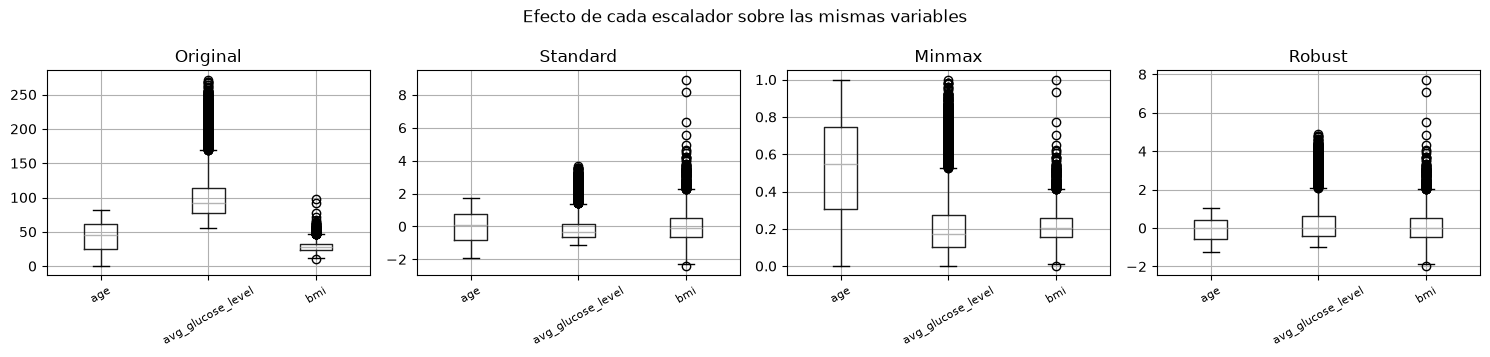

In [57]:
fig, ejes = plt.subplots(1, 4, figsize=(15, 3.6))   # cuatro paneles en una fila

# zip recorre en paralelo los paneles y los resultados: cada uno va al suyo
for eje, (nombre, valores) in zip(ejes, resultados.items()):
    valores.boxplot(ax=eje)
    eje.set_title(nombre.capitalize())
    # Los nombres de variable son largos: rotarlos evita que se solapen
    eje.tick_params(axis="x", rotation=30, labelsize=8)

plt.suptitle("Efecto de cada escalador sobre las mismas variables")
plt.tight_layout()
plt.show()

In [58]:
def verificar_escalamiento(valores, metodo, tol=1e-9):
    """Comprueba que el escalamiento produjo lo que el método promete.

    Cada escalador garantiza una propiedad distinta, así que la verificación
    también debe serlo: comprobar siempre lo mismo no valida nada.
    """
    if metodo == "standard":
        # np.allclose compara con tolerancia; exigir igualdad exacta entre
        # decimales fallaría por diferencias del orden de 1e-17.
        assert np.allclose(valores.mean(), 0, atol=tol), "media distinta de 0"
        # ddof=0 pide la desviación POBLACIONAL, que es la que usa StandardScaler;
        # pandas usa ddof=1 por defecto y no daría exactamente 1.
        assert np.allclose(valores.std(ddof=0), 1, atol=tol), "desviación distinta de 1"
        return "media ≈ 0 y desviación ≈ 1"
    if metodo == "minmax":
        assert np.allclose(valores.min(), 0, atol=tol), "mínimo distinto de 0"
        assert np.allclose(valores.max(), 1, atol=tol), "máximo distinto de 1"
        return "todos los valores en el rango [0, 1]"
    if metodo == "robust":
        assert np.allclose(valores.median(), 0, atol=1e-8), "mediana distinta de 0"
        ric = valores.quantile(0.75) - valores.quantile(0.25)
        assert np.allclose(ric, 1, atol=1e-8), "rango intercuartílico distinto de 1"
        return "mediana ≈ 0 y rango intercuartílico ≈ 1"
    raise ValueError(f"Método desconocido: {metodo}")


for metodo in ["standard", "minmax", "robust"]:
    print(f"[OK] {metodo:<9} {verificar_escalamiento(resultados[metodo]['bmi'], metodo)}")

[OK] standard  media ≈ 0 y desviación ≈ 1
[OK] minmax    todos los valores en el rango [0, 1]
[OK] robust    mediana ≈ 0 y rango intercuartílico ≈ 1


> **Coherencia entre decisiones.** Si se imputó con la mediana *porque hay
> valores extremos*, la misma evidencia apunta a `RobustScaler`. Usar mediana
> para imputar y `StandardScaler` para escalar no está prohibido, pero exige
> explicar por qué el mismo hecho lleva a criterios distintos. Eso separa un
> pipeline pensado de una sucesión de pasos.

## 6. Validación técnica y verificación del código

Verificar significa demostrar, con evidencia, que el resultado es correcto. La función
`validar_dataset` ejecuta varias comprobaciones y usa `assert`: si una condición no se
cumple, el notebook se detiene con un error, dejando constancia de la falla.

Comprobamos:
1. **Integridad** — que no queden valores nulos.
2. **Consistencia** — que todas las columnas sean numéricas (no quedó texto sin codificar).
3. **Coherencia** — que cada grupo one-hot sume exactamente 1 por fila: cada paciente
   pertenece a **una sola** categoría dentro de cada variable.
4. **Duplicados** — cuántas filas repetidas hay.
5. **Dimensiones** — la forma final de la tabla.

In [59]:
def validar_dataset(df, grupos_one_hot=None):
    """
    Comprueba integridad, consistencia y coherencia del dataset final.
    Lanza AssertionError si alguna comprobacion falla.
    """
    print("VALIDACION DEL DATASET FINAL")
    print("-" * 45)

    # 1. Integridad: sin valores nulos
    nulos = int(df.isnull().sum().sum())
    assert nulos == 0, f"Quedan {nulos} valores nulos."
    print(f"[OK] Sin valores nulos (total = {nulos})")

    # 2. Consistencia: todas las columnas son numericas
    no_numericas = df.select_dtypes(exclude=[np.number]).columns.tolist()
    assert not no_numericas, f"Columnas no numericas: {no_numericas}"
    print("[OK] Todas las columnas son numericas")

    # 3. Coherencia: cada grupo one-hot suma 1 por fila (una sola categoria activa)
    if grupos_one_hot:
        for nombre, cols in grupos_one_hot.items():
            suma = df[cols].sum(axis=1)
            assert (suma == 1).all(), f"El grupo '{nombre}' no suma 1 en todas las filas."
            print(f"[OK] Grupo one-hot '{nombre}' coherente")

    # 4. Duplicados
    dup = int(df.duplicated().sum())
    print(f"[INFO] Filas duplicadas: {dup}")

    # 5. Dimensiones finales
    print(f"[INFO] Dimensiones finales: {df.shape}")
    return True


grupos = {
    'gender': ['gender_Female', 'gender_Male', 'gender_Other'],
    'ever_married': ['married_No', 'married_Yes'],
    'work_type': ['work_Govt', 'work_Never', 'work_Private', 'work_Self', 'work_children'],
    'Residence_type': ['res_Rural', 'res_Urban'],
    'smoking_status': ['smoke_Unknown', 'smoke_formerly', 'smoke_never', 'smoke_smokes'],
}
validar_dataset(df, grupos)

VALIDACION DEL DATASET FINAL
---------------------------------------------
[OK] Sin valores nulos (total = 0)
[OK] Todas las columnas son numericas
[OK] Grupo one-hot 'gender' coherente
[OK] Grupo one-hot 'ever_married' coherente
[OK] Grupo one-hot 'work_type' coherente
[OK] Grupo one-hot 'Residence_type' coherente
[OK] Grupo one-hot 'smoking_status' coherente
[INFO] Filas duplicadas: 0
[INFO] Dimensiones finales: (5110, 23)


True

### Pruebas de las funciones (casos normal, límite y excepciones)

Además de validar el *dataset*, probamos la función de codificación en tres escenarios,
tal como pide la rúbrica:
- **Caso normal:** una columna pequeña y conocida; verificamos que produzca el número
  correcto de columnas y que cada fila tenga una sola categoría activa.
- **Excepción 1:** se pasa una cantidad equivocada de nombres → debe lanzar `ValueError`.
- **Excepción 2:** se pide codificar una columna inexistente → debe lanzar `KeyError`.

In [60]:
# --- Caso normal ---
prueba = pd.DataFrame({'color': ['rojo', 'azul', 'rojo', 'verde']})
res = codificar_one_hot(prueba, 'color', ['azul', 'rojo', 'verde'])
assert res.shape == (4, 3), "Numero de columnas inesperado."
assert (res.sum(axis=1) == 1).all(), "Cada fila debe tener una sola categoria activa."
print("[OK] Caso normal: codificacion correcta")

# --- Excepcion 1: numero de nombres incorrecto ---
try:
    codificar_one_hot(prueba, 'color', ['azul', 'rojo'])
except ValueError as e:
    print(f"[OK] Excepcion capturada (nombres): {e}")

# --- Excepcion 2: columna inexistente ---
try:
    codificar_one_hot(prueba, 'inexistente', ['x'])
except KeyError as e:
    print(f"[OK] Excepcion capturada (columna): {e}")

[OK] Caso normal: codificacion correcta
[OK] Excepcion capturada (nombres): Se esperaban 3 nombres para 'color' (['azul', 'rojo', 'verde']), pero se recibieron 2.
[OK] Excepcion capturada (columna): "La columna 'inexistente' no existe en el DataFrame."


### Visualización de control

El *boxplot* de las variables continuas ya estandarizadas confirma que quedaron centradas
alrededor de 0 y en una escala comparable. Los puntos alejados de las cajas son los valores
atípicos que motivaron usar la mediana en la imputación.

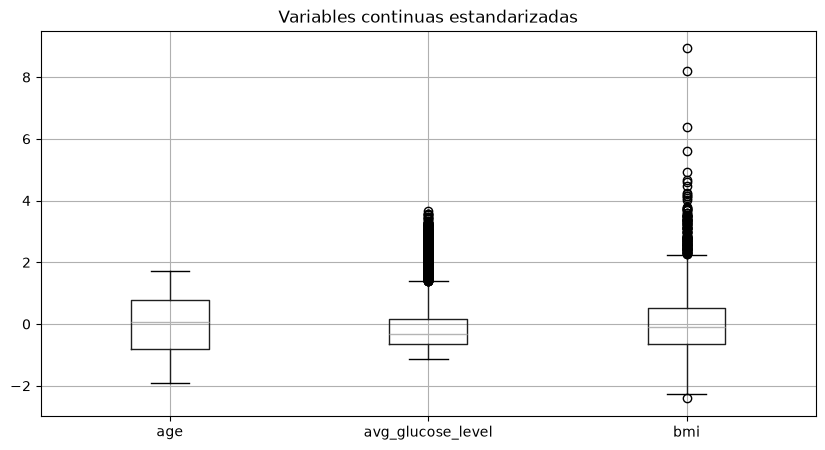

In [61]:
# El boxplot muestra mediana, cuartiles y atípicos: tras estandarizar, las tres
# cajas deben quedar centradas en torno a 0 y con anchos comparables.
df[columnas_continuas].boxplot(figsize=(10, 5))
plt.title("Variables continuas estandarizadas")
plt.show()

Vista final del *dataset* completamente preprocesado:

In [62]:
# Vista final: las columnas de texto desaparecieron y en su lugar hay columnas
# binarias; las continuas quedaron estandarizadas.
print("Dataset final:", df.shape)
df.head()

Dataset final: (5110, 23)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,bmi_imputado,gender_Female,gender_Male,gender_Other,...,work_Never,work_Private,work_Self,work_children,res_Rural,res_Urban,smoke_Unknown,smoke_formerly,smoke_never,smoke_smokes
0,1.051434,0,1,2.706375,1.005086,1,0,0,1,0,...,0,1,0,0,0,1,0,1,0,0
1,0.786070,0,0,2.121559,-0.098981,1,1,1,0,0,...,0,0,1,0,1,0,0,0,1,0
2,1.626390,0,1,-0.005028,0.472536,1,0,0,1,0,...,0,1,0,0,1,0,0,0,1,0
3,0.255342,0,0,1.437358,0.719327,1,0,1,0,0,...,0,1,0,0,0,1,0,0,0,1
4,1.582163,1,0,1.501184,-0.631531,1,0,1,0,0,...,0,0,1,0,1,0,0,0,1,0


## Conclusiones y trazabilidad

El *pipeline* dejó el *dataset* sin valores nulos, con todas las variables en formato
numérico y las continuas estandarizadas. Cada paso se implementó como una función
documentada y reutilizable (`cargar_datos`, `explorar_dataframe`, `imputar_nulos_numericos`,
`codificar_one_hot`, `escalar_caracteristicas`, `validar_dataset`), garantizando un flujo
modular, reproducible y verificable.

**Trazabilidad con el repositorio (F2):** este notebook se ubica en la carpeta `F2/` del
repositorio GitHub; el `README` documenta las dependencias (`numpy`, `pandas`,
`scikit-learn`, `matplotlib`) y las instrucciones de ejecución. El historial de *commits*
refleja el avance del *pipeline* descrito en el informe técnico de la Fase 2.

---

## 7. Recursividad: aplanar los metadatos del proyecto

Todo el procesamiento anterior fue **estructurado**: secuencias, condicionales y
bucles. Esta sección introduce la **recursividad**, que es la herramienta natural
cuando la estructura tiene profundidad desconocida. El indicador ID 2.1 la
contempla explícitamente.

El caso es real y no decorativo: los metadatos del proyecto forman un diccionario
anidado y, para exportarlos como tabla, hay que convertirlos en pares
clave-valor. Un bucle no sirve porque no se sabe cuántos niveles hay.

**Anatomía de la función recursiva:**
- *Caso base*: el valor no es un diccionario → se devuelve el par clave-valor.
- *Caso recursivo*: el valor es un diccionario → la función se llama a sí misma
  un nivel más abajo, arrastrando el prefijo de la ruta.

In [63]:
# Los metadatos del proyecto, con la estructura anidada que corresponde
METADATOS = {
    "proyecto": {
        "nombre": "Predicción de accidente cerebrovascular",
        "fase": "F2",
        "semilla": 42,
    },
    "datos": {
        "archivo": "healthcare-dataset-stroke-data.csv",
        "fuente": {
            "plataforma": "Kaggle",
            "autor": "fedesoriano",
            "url": "https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset",
        },
    },
    "decisiones": {
        "imputacion": {"bmi": "mediana"},
        "escalador": "standard",
        "categoricas": ["gender", "ever_married", "work_type",
                        "Residence_type", "smoking_status"],
    },
}


def aplanar(estructura, prefijo="", separador="."):
    """Aplana un diccionario anidado en uno de un solo nivel.

    Ejemplo
    -------
    >>> aplanar({"a": {"b": 1, "c": {"d": 2}}})
    {'a.b': 1, 'a.c.d': 2}
    """
    plano = {}
    for clave, valor in estructura.items():
        # Se construye la ruta completa: en el primer nivel no hay prefijo
        ruta = f"{prefijo}{separador}{clave}" if prefijo else str(clave)

        if isinstance(valor, dict):
            # CASO RECURSIVO: la función se llama a sí misma un nivel más abajo
            plano.update(aplanar(valor, ruta, separador))
        elif isinstance(valor, (list, tuple)):
            # Las secuencias se convierten en texto legible para la tabla
            plano[ruta] = ", ".join(str(v) for v in valor)
        else:
            # CASO BASE: el valor es simple, se devuelve el par
            plano[ruta] = valor
    return plano


metadatos_planos = aplanar(METADATOS)
print(f"El diccionario anidado se aplanó en {len(metadatos_planos)} pares.\n")
for clave, valor in metadatos_planos.items():
    print(f"  {clave:<28} {str(valor)[:52]}")

El diccionario anidado se aplanó en 10 pares.

  proyecto.nombre              Predicción de accidente cerebrovascular
  proyecto.fase                F2
  proyecto.semilla             42
  datos.archivo                healthcare-dataset-stroke-data.csv
  datos.fuente.plataforma      Kaggle
  datos.fuente.autor           fedesoriano
  datos.fuente.url             https://www.kaggle.com/datasets/fedesoriano/stroke-p
  decisiones.imputacion.bmi    mediana
  decisiones.escalador         standard
  decisiones.categoricas       gender, ever_married, work_type, Residence_type, smo


In [64]:
# Verificación de la función recursiva: casos normal, profundo y límite
assert aplanar({"a": 1}) == {"a": 1}, "Caso plano"
assert aplanar({"a": {"b": 1}}) == {"a.b": 1}, "Un nivel de anidamiento"
assert aplanar({"a": {"b": {"c": {"d": 4}}}}) == {"a.b.c.d": 4}, "Anidamiento profundo"
assert aplanar({}) == {}, "Caso límite: diccionario vacío"
assert aplanar({"x": [1, 2, 3]}) == {"x": "1, 2, 3"}, "Listas convertidas a texto"
print("[OK] La función recursiva pasa las cinco pruebas.")

[OK] La función recursiva pasa las cinco pruebas.


> **Cuándo NO usar recursividad.** Si la profundidad se conoce y es fija, un
> bucle anidado es más claro y más rápido. La recursividad se justifica cuando la
> profundidad es variable, como aquí. Python además limita la profundidad a unos
> mil niveles, así que no reemplaza a un bucle sobre miles de filas.

---

## 8. Persistencia y trazabilidad

El resultado debe quedar guardado y documentado. Esta sección produce los
artefactos que se versionan en el repositorio y se citan en el informe.

In [65]:
ARCHIVO_PROCESADO = DIR_PROCESADO / "stroke_procesado.csv"

# index=False evita agregar una columna con el número de fila, que no es un dato
df.to_csv(ARCHIVO_PROCESADO, index=False)

# Verificación de ida y vuelta: se relee lo guardado y se comprueba que coincide.
# Si el archivo se escribió mal, es preferible descubrirlo ahora.
releido = pd.read_csv(ARCHIVO_PROCESADO)
assert releido.shape == df.shape, "El archivo releído no coincide en dimensiones"
print(f"Guardado y verificado: {ARCHIVO_PROCESADO}")
print(f"Tamaño en disco: {ARCHIVO_PROCESADO.stat().st_size / 1024:.1f} kB")

# Los metadatos aplanados con la función recursiva de la sección 7
pd.DataFrame(list(metadatos_planos.items()), columns=["clave", "valor"]).to_csv(
    DIR_DOCS / "metadatos_proyecto.csv", index=False)
print(f"Metadatos exportados a {DIR_DOCS}/metadatos_proyecto.csv")

Guardado y verificado: data/processed/stroke_procesado.csv
Tamaño en disco: 495.1 kB
Metadatos exportados a docs/metadatos_proyecto.csv


In [66]:
# Resumen comparativo entre el punto de partida y el resultado.
# Esta tabla responde de una vez a la pregunta "qué cambió".
resumen = pd.DataFrame([
    {"indicador": "Filas", "inicial": df_crudo.shape[0], "final": df.shape[0]},
    {"indicador": "Columnas", "inicial": df_crudo.shape[1], "final": df.shape[1]},
    {"indicador": "Valores nulos",
     "inicial": int(df_crudo.isna().sum().sum()), "final": int(df.isna().sum().sum())},
    {"indicador": "Columnas de texto",
     "inicial": int((df_crudo.dtypes == "object").sum()),
     "final": int((df.dtypes == "object").sum())},
    {"indicador": "Filas duplicadas",
     "inicial": int(df_crudo.duplicated().sum()), "final": int(df.duplicated().sum())},
])
resumen

,indicador,inicial,final
0,Filas,5110,5110
1,Columnas,12,23
2,Valores nulos,201,0
3,Columnas de texto,0,0
4,Filas duplicadas,0,0


---

## 9. Reflexión técnica

Este apartado es obligatorio en la entrega. Redáctenlo con **sus** cifras.

### Hallazgos

- **Desbalance de la variable objetivo.** Los casos positivos son una fracción
  pequeña de la muestra. No afecta al preprocesamiento, pero condiciona la
  evaluación: un procedimiento que siempre prediga la clase mayoritaria parecerá
  acertar sin haber aprendido nada.

- **Asimetría en las variables continuas.** La tabla de atípicos mostró la
  distancia entre media y mediana en `bmi` y `avg_glucose_level`. Ese hecho —y no
  una preferencia— justificó imputar con la mediana.

- **`Unknown` no es un valor faltante.** En `smoking_status` representa cerca de
  un tercio de la muestra. Tratarlo como nulo habría implicado imputar esa
  proporción; se conservó como categoría propia.

### Dificultades y cómo se resolvieron

- **Los faltantes venían como el texto `N/A`.** Se declararon con `na_values` en
  la carga, dejando constancia de que fue una decisión.

- **La codificación depende del orden alfabético interno.** La función
  `codificar_one_hot` exige escribir los nombres en ese orden; la sección 4 mostró
  la alternativa con `get_feature_names_out`, que los genera sola.

### Decisiones que quedan abiertas

- Si `smoking_status` conviene tratarla como ordinal en lugar de nominal.
- Si el desbalance exige un tratamiento específico en las fases siguientes.
- Si la partición entre entrenamiento y prueba obligará a rehacer la imputación y
  el escalamiento dentro de un `Pipeline` de scikit-learn.

> **Declarar lo que queda abierto evidencia más dominio que presentar todo
> resuelto.** En esta fase no debería estarlo.

---

## 10. Verificación antes de entregar

**Notebook**

- Corre completo tras *Kernel → Restart Kernel and Run All Cells*, sin errores.
- La numeración de ejecución es continua.
- Cada bloque de código está precedido por una celda narrativa que explica su lógica.
- Todas las rutas son relativas y la semilla está declarada.

**Contenido técnico**

- La procedencia del conjunto está documentada, con enlace y cita en APA 7.
- El diccionario de variables declara el rol analítico de cada una.
- Las decisiones de imputación y escalamiento están **comparadas y justificadas con cifras**.
- Hay pruebas de casos normales, límite y excepciones.

**Archivos**

- `data/raw/` conserva el archivo original sin modificar.
- `data/processed/` contiene el conjunto procesado.
- `docs/` contiene el diccionario de variables y los metadatos.

**Repositorio**

- Carpeta F2 con este notebook, commits de todos los integrantes y README actualizado.

---

*Cuaderno de la Fase 2 · MCDI500 · Magíster en Ciencia de Datos e Inteligencia
Artificial · Universidad Andrés Bello*